# CS506 Midterm — Amazon Review Rating Prediction
Ridge Regression + user/product bias features + TF-IDF

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.data import load_train_data, load_test_data
from src.features import prepare_training_data, prepare_test_data
from src.model import train_ridge, evaluate_model, save_model, create_submission

## 1. Load data
The test IDs are embedded in train.csv with NaN scores — we extract them here.

In [2]:
raw = load_train_data('../data/train.csv')
test_ids_df = load_test_data('../data/test.csv')

# Split labeled vs unlabeled
labeled   = raw.dropna(subset=['Score']).copy()
test_df   = raw[raw['Id'].isin(test_ids_df['Id'])].copy()

print('Labeled rows :', len(labeled))
print('Test rows    :', len(test_df))
print('Score distribution:')
print(labeled['Score'].value_counts().sort_index())

Labeled rows : 125777
Test rows    : 13976
Score distribution:
Score
1.0     7593
2.0     7567
3.0    14857
4.0    28572
5.0    67188
Name: count, dtype: int64


## 2. Honest validation — split first, fit on train fold only

To avoid data leakage, we split the labeled DataFrame **before** fitting any transformers.
Bias features and TF-IDF are fit on the train fold only, then applied to the validation fold.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text as sk_text
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from scipy.sparse import hstack, csr_matrix
from src.features import build_bias_features, build_numeric_features

labeled = raw.dropna(subset=['Score']).copy()

# Split labeled DataFrame FIRST — no leakage
train_df, valid_df = train_test_split(labeled, test_size=0.2, random_state=42, stratify=labeled['Score'])
print('Train fold:', len(train_df), '  Valid fold:', len(valid_df))

# --- Fit TF-IDF on train fold only ---
movie_stop = {"movie", "film", "watch", "watched", "one", "really", "also", "even", "get", "got", "make", "made"}
stop_words = list(sk_text.ENGLISH_STOP_WORDS.union(movie_stop))

tfidf_val = TfidfVectorizer(
    lowercase=True, stop_words=stop_words, ngram_range=(1,2),
    min_df=3, max_df=0.9, sublinear_tf=True, norm='l2',
    smooth_idf=True, use_idf=True, max_features=30000
)
train_text = train_df['Summary'].fillna('').astype(str) + ' ' + train_df['Text'].fillna('').astype(str)
valid_text = valid_df['Summary'].fillna('').astype(str) + ' ' + valid_df['Text'].fillna('').astype(str)

X_text_tr = tfidf_val.fit_transform(train_text)
X_text_va = tfidf_val.transform(valid_text)

# --- Fit SVD on train fold only ---
svd_val = TruncatedSVD(n_components=200, random_state=42)
X_lsa_tr = Normalizer().fit_transform(svd_val.fit_transform(X_text_tr))
X_lsa_va = Normalizer().fit_transform(svd_val.transform(X_text_va))

# --- Bias features: compute from train fold only ---
num_cols = build_numeric_features(train_df).columns.tolist()

bias_tr = build_bias_features(train_df, train_df)
bias_va = build_bias_features(train_df, valid_df)   # <-- train fold as source

num_tr = build_numeric_features(train_df).values
num_va = build_numeric_features(valid_df).reindex(columns=num_cols, fill_value=0).fillna(0).values

X_train = hstack([csr_matrix(num_tr), csr_matrix(bias_tr), X_text_tr, csr_matrix(X_lsa_tr)])
X_valid = hstack([csr_matrix(num_va), csr_matrix(bias_va), X_text_va, csr_matrix(X_lsa_va)])
y_train = train_df['Score'].values
y_valid = valid_df['Score'].values

print('X_train:', X_train.shape)
print('X_valid:', X_valid.shape)

Train fold: 100621   Valid fold: 25156


X_train: (100621, 30221)
X_valid: (25156, 30221)


## 4. Model: Ridge Regression
Ridge works well with high-dimensional sparse TF-IDF features. Alpha tuned by validation RMSE.

In [4]:
best_rmse = 999
best_alpha = None
results = []

for alpha in [0.1, 1.0, 5.0, 10.0, 50.0, 100.0]:
    model = train_ridge(X_train, y_train, alpha=alpha)
    rmse = evaluate_model(model, X_train, X_valid, y_train, y_valid, title=f'Ridge alpha={alpha}')
    results.append((alpha, rmse))
    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = alpha

print(f'\nBest alpha: {best_alpha}  |  Best valid RMSE: {best_rmse:.4f}')


Ridge alpha=0.1
  Train RMSE : 0.6979
  Valid RMSE : 0.8694



Ridge alpha=1.0
  Train RMSE : 0.6980
  Valid RMSE : 0.8696



Ridge alpha=5.0
  Train RMSE : 0.6981
  Valid RMSE : 0.8704



Ridge alpha=10.0
  Train RMSE : 0.6983
  Valid RMSE : 0.8714



Ridge alpha=50.0
  Train RMSE : 0.6997
  Valid RMSE : 0.8785



Ridge alpha=100.0
  Train RMSE : 0.7021
  Valid RMSE : 0.8871

Best alpha: 0.1  |  Best valid RMSE: 0.8694


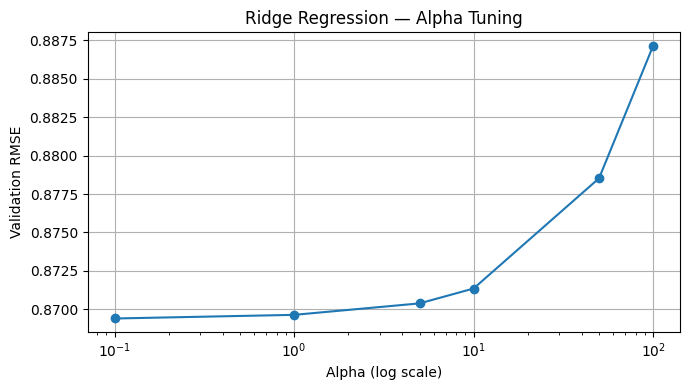

In [5]:
alphas, rmses = zip(*results)
plt.figure(figsize=(7, 4))
plt.semilogx(alphas, rmses, marker='o')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Validation RMSE')
plt.title('Ridge Regression — Alpha Tuning')
plt.grid(True)
plt.tight_layout()
plt.savefig('../assets/ridge_alpha_tuning.png', dpi=100)
plt.show()

## 5. Train final model on all labeled data

In [6]:
# Train final model on ALL labeled data (no leakage concern — we're not evaluating on it)
X_final, y_final, tfidf, svd, numeric_columns, labeled_df = prepare_training_data(
    raw, text_column='Text', max_features=30000, ngram_range=(1, 2)
)

final_model = train_ridge(X_final, y_final, alpha=best_alpha)
save_model(final_model, '../ridge_regression_model.obj')
print('Final model trained and saved. Alpha:', best_alpha)

TF-IDF matrix shape: (125777, 30000)


LSA explained variance: 0.136


Final model trained and saved. Alpha: 0.1


## 6. Prepare test features and generate submission

In [7]:
X_test = prepare_test_data(test_df, tfidf, svd, numeric_columns, labeled_df)
print('Test feature matrix shape:', X_test.shape)

submission = create_submission(
    final_model,
    test_df,
    X_test,
    output_path='../submissions/submission.csv',
    clip_range=(1, 5),
    round_predictions=False
)
print(submission.describe())
submission.head(10)

Test feature matrix shape: (13976, 30221)
Submission saved to ../submissions/submission.csv (13976 rows)
                 Id         Score
count  1.397600e+04  13976.000000
mean   8.473832e+05      4.088079
std    4.887796e+05      0.765488
min    6.300000e+01      1.000000
25%    4.237660e+05      3.696080
50%    8.522600e+05      4.260342
75%    1.269030e+06      4.663068
max    1.697410e+06      5.000000


,Id,Score
125777,1224650,3.995644
125778,1019381,3.889117
125779,504719,4.538790
125780,1622425,4.410952
125781,482286,4.620546
125782,1074829,4.196157
125783,1599357,3.913456
125784,1087427,4.908557
125785,203315,2.908779
125786,235783,4.790625


## 7. Score distribution check

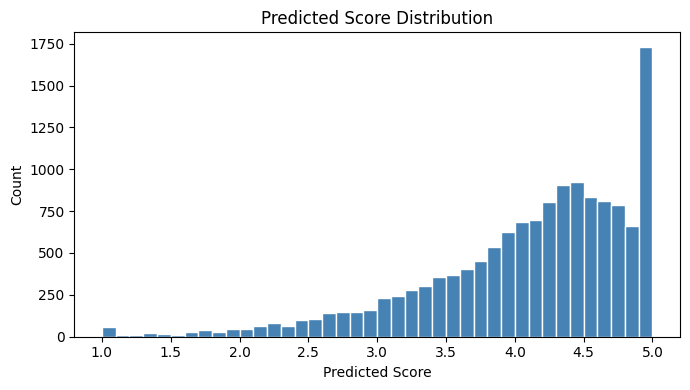

Validation RMSE (best): 0.8694


In [8]:
plt.figure(figsize=(7, 4))
plt.hist(submission['Score'], bins=40, color='steelblue', edgecolor='white')
plt.xlabel('Predicted Score')
plt.ylabel('Count')
plt.title('Predicted Score Distribution')
plt.tight_layout()
plt.savefig('../assets/predicted_score_dist.png', dpi=100)
plt.show()
print('Validation RMSE (best):', round(best_rmse, 4))